In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import json
import torch
import os
import copy
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import multilabel_confusion_matrix, classification_report, roc_curve, auc, confusion_matrix, \
     RocCurveDisplay, precision_score, recall_score, average_precision_score, PrecisionRecallDisplay, precision_recall_curve, roc_auc_score
from tqdm import tqdm
from matplotlib.pyplot import figure


In [2]:
from matplotlib import rc, rcParams
rc('axes', linewidth=1)
rc('font', size=7)
plt.rcParams['font.family'] = 'Arial'

In [3]:
cog_labels = ['amy_label', 'tau_label']

In [4]:
def gen_roc_pr(y_true, y_pred, cog_labels, subgroup, fname):
    for i, fea in enumerate(cog_labels):
        y_true_ = np.array(y_true[:, i])
        y_pred_ = np.array(y_pred[:, i])
        mask = np.array([1 if not np.isnan(k) else 0 for k in y_true_])
        masked_y_true = y_true_[np.where(mask == 1)]
        masked_y_pred = y_pred_[np.where(mask == 1)]
        # fpr[fea], tpr[fea], thresholds[fea] = roc_curve(y_true=masked_y_true, y_score=masked_y_pred, pos_label=1, drop_intermediate=False)
        auc_score = roc_auc_score(masked_y_true, masked_y_pred)
        aupr_score = average_precision_score(masked_y_true, masked_y_pred)
        
        if "amy" in fea:
            perf_dict_amy[subgroup][fname]['AUROC'] = round(auc_score, 2)
            perf_dict_amy[subgroup][fname]['AUPR'] = round(aupr_score, 2)
        else:
            perf_dict_tau[subgroup][fname]['AUROC'] = round(auc_score, 2)
            perf_dict_tau[subgroup][fname]['AUPR'] = round(aupr_score, 2)
            

In [5]:
def roc_pr(sub_df, fname, subgroup):
    y_true_ =  np.array(sub_df[[f'{lab}_label' for lab in cog_labels]])
    scores_proba_ = np.array(sub_df[[f'{lab}_prob' for lab in cog_labels]])
    
    gen_roc_pr(y_true_, scores_proba_, cog_labels, subgroup, fname)
    

In [6]:
perf_dict_amy = {"sex": {"male": {}, "female": {}}, "age": {"age_above_median": {}, "age_below_median": {}}, "race": {"whi": {}, "oth": {}}, "educ": {"educ_above_median": {}, "educ_below_median": {}}}
perf_dict_tau = {"sex": {"male": {}, "female": {}}, "age": {"age_above_median": {}, "age_below_median": {}}, "race": {"whi": {}, "oth": {}}, "educ": {"educ_above_median": {}, "educ_below_median": {}}}

In [7]:
basedir = "./source_data/efig1"
efig1a_female = pd.read_csv(f"{basedir}/efig1b_female.csv")
efig1a_male = pd.read_csv(f"{basedir}/efig1b_male.csv")
efig1a_whi = pd.read_csv(f"{basedir}/efig1c_whi.csv")
efig1a_oth = pd.read_csv(f"{basedir}/efig1c_oth.csv")
efig1a_age_above_median = pd.read_csv(f"{basedir}/efig1a_age_above_median.csv")
efig1a_age_below_median = pd.read_csv(f"{basedir}/efig1a_age_below_median.csv")
efig1d_educ_above_median = pd.read_csv(f"{basedir}/efig1d_educ_above_median.csv")
efig1d_educ_below_median = pd.read_csv(f"{basedir}/efig1d_educ_below_median.csv")

In [8]:
roc_pr(efig1a_female, "female", "sex")
roc_pr(efig1a_male, "male", "sex")
roc_pr(efig1a_whi, "whi", "race")
roc_pr(efig1a_oth, "oth", "race")
roc_pr(efig1a_age_above_median, "age_above_median", "age")
roc_pr(efig1a_age_below_median, "age_below_median", "age")
roc_pr(efig1d_educ_above_median, "educ_above_median", "educ")
roc_pr(efig1d_educ_below_median, "educ_below_median", "educ")

In [9]:
perf_dict_amy

{'sex': {'male': {'AUROC': 0.79, 'AUPR': 0.76},
  'female': {'AUROC': 0.79, 'AUPR': 0.8}},
 'age': {'age_above_median': {'AUROC': 0.76, 'AUPR': 0.78},
  'age_below_median': {'AUROC': 0.8, 'AUPR': 0.78}},
 'race': {'whi': {'AUROC': 0.79, 'AUPR': 0.79},
  'oth': {'AUROC': 0.78, 'AUPR': 0.73}},
 'educ': {'educ_above_median': {'AUROC': 0.78, 'AUPR': 0.75},
  'educ_below_median': {'AUROC': 0.8, 'AUPR': 0.84}}}

In [10]:
perf_dict_tau

{'sex': {'male': {'AUROC': 0.79, 'AUPR': 0.48},
  'female': {'AUROC': 0.87, 'AUPR': 0.72}},
 'age': {'age_above_median': {'AUROC': 0.78, 'AUPR': 0.56},
  'age_below_median': {'AUROC': 0.88, 'AUPR': 0.67}},
 'race': {'whi': {'AUROC': 0.83, 'AUPR': 0.61},
  'oth': {'AUROC': 0.91, 'AUPR': 0.61}},
 'educ': {'educ_above_median': {'AUROC': 0.8, 'AUPR': 0.49},
  'educ_below_median': {'AUROC': 0.91, 'AUPR': 0.79}}}

In [11]:
rows = []
for subgroup, categories in perf_dict_amy.items():
    for category, metrics in categories.items():
        rows.append({'Subgroup': subgroup, 'Category': category, 'AUROC': metrics['AUROC'], 'AUPR': metrics['AUPR'], "Label" : "amy_label"})

df1 = pd.DataFrame(rows)

rows = []
for subgroup, categories in perf_dict_tau.items():
    for category, metrics in categories.items():
        rows.append({'Subgroup': subgroup, 'Category': category, 'AUROC': metrics['AUROC'], 'AUPR': metrics['AUPR'], "Label" : "tau_label"})

df2 = pd.DataFrame(rows)

data = pd.concat([df1, df2], axis=0).reset_index(drop=True)

In [12]:
data

,Subgroup,Category,AUROC,AUPR,Label
0,sex,male,0.79,0.76,amy_label
1,sex,female,0.79,0.80,amy_label
2,age,age_above_median,0.76,0.78,amy_label
3,age,age_below_median,0.80,0.78,amy_label
4,race,whi,0.79,0.79,amy_label
5,race,oth,0.78,0.73,amy_label
6,educ,educ_above_median,0.78,0.75,amy_label
7,educ,educ_below_median,0.80,0.84,amy_label
8,sex,male,0.79,0.48,tau_label
9,sex,female,0.87,0.72,tau_label


In [13]:
df = data.copy()

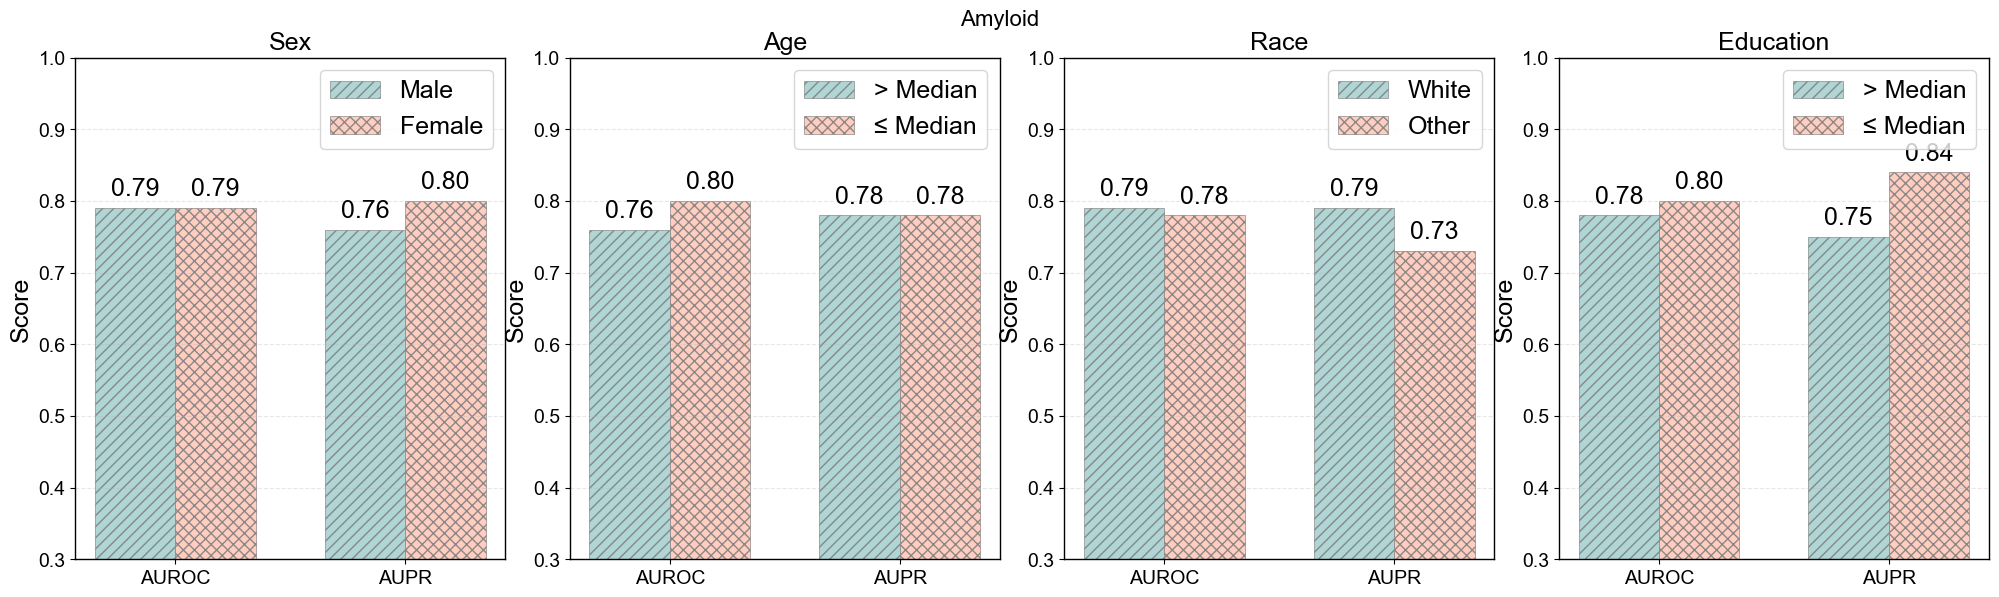

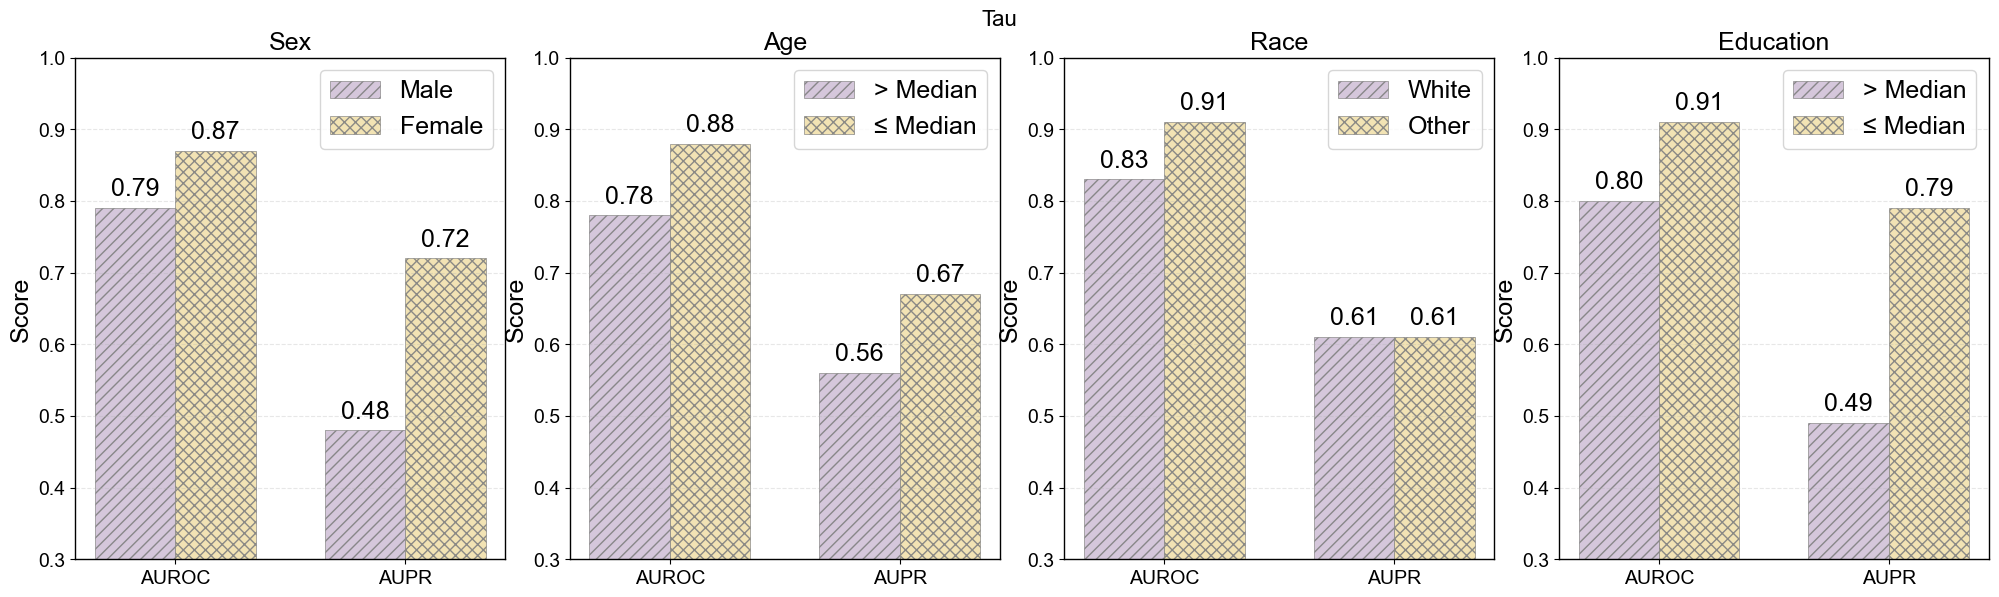

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


amy_data = df[df['Label'] == 'amy_label'].reset_index(drop=True)
tau_data = df[df['Label'] == 'tau_label'].reset_index(drop=True)

amyloid_colors = {
    'cat1': '#A8D1D1',
    'cat2': '#FFC9B9',
}
tau_colors = {
    'cat1': '#D1C1D7',
    'cat2': '#F1E0AC', 
}

hatches = {
    'cat1': '///',
    'cat2': 'xxx' 
}

# Gray color for hatching
hatch_color = '#808080' 

fontsizes = 18
tick_fontsize = 14

def create_model_subplots(model_data, model_name, colors, y_min, y_max, filename):
    fig, axs = plt.subplots(1, 4, figsize=(20, 6))
    subgroups = ['sex', 'age', 'race', 'educ']
    subgroup_labels = {
        'sex': 'Sex',
        'age': 'Age',
        'race': 'Race',
        'educ': 'Education'
    }
    category_labels = {
        'male': 'Male',
        'female': 'Female',
        'age_above_median': '> Median',
        'age_below_median': '≤ Median',
        'whi': 'White',
        'oth': 'Other',
        'educ_above_median': '> Median',
        'educ_below_median': '≤ Median'
    }
    
    for i, subgroup in enumerate(subgroups):
        ax = axs[i]
        subgroup_data = model_data[model_data['Subgroup'] == subgroup].reset_index(drop=True)
        categories = subgroup_data['Category'].tolist()
        x = np.arange(2) 
        width = 0.35 
        
        cat1_bars = ax.bar(x - width/2,
                          [subgroup_data.iloc[0]['AUROC'], subgroup_data.iloc[0]['AUPR']],
                          width, color=colors['cat1'], alpha=0.9,
                          edgecolor='black', linewidth=0.5,
                          label=category_labels[categories[0]], 
                          hatch=hatches['cat1'])
        
        cat2_bars = ax.bar(x + width/2,
                          [subgroup_data.iloc[1]['AUROC'], subgroup_data.iloc[1]['AUPR']],
                          width, color=colors['cat2'], alpha=0.9,
                          edgecolor='black', linewidth=0.5,
                          label=category_labels[categories[1]], 
                          hatch=hatches['cat2'])

        for bar in cat1_bars:
            bar.set_hatch(hatches['cat1'])
            bar.set_edgecolor(hatch_color)
        
        for bar in cat2_bars:
            bar.set_hatch(hatches['cat2'])
            bar.set_edgecolor(hatch_color)
        
        for j, bar in enumerate(cat1_bars):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f"{height:.2f}", ha='center', va='bottom', fontsize=fontsizes)
        
        for j, bar in enumerate(cat2_bars):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f"{height:.2f}", ha='center', va='bottom', fontsize=fontsizes)
        
        ax.set_ylabel('Score', fontsize=fontsizes)
        ax.set_title(f'{subgroup_labels[subgroup]}', fontsize=fontsizes)
        
        ax.set_ylim(y_min, y_max)
        
        ax.set_xticks(x)
        ax.set_xticklabels(['AUROC', 'AUPR'], fontsize=tick_fontsize)
        
        ax.tick_params(axis='y', labelsize=tick_fontsize)
        
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        
        ax.legend(loc='upper right', fontsize=fontsizes)
    
    fig.suptitle(f'{model_name}', fontsize=16, y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.15, top=0.9)
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

create_model_subplots(amy_data, 'Amyloid', amyloid_colors, 0.3, 1, 'pdf_plots/efig1a.pdf')
create_model_subplots(tau_data, 'Tau', tau_colors, 0.3, 1, 'pdf_plots/efig1b.pdf')